# Assignment 7: Planning and Learning Integration

Planning and Learning Integration Lab: Dyna-Q, Dyna-Q+, and Prioritized Sweeping 

Step 1: Install and import the required libraries

In [1]:
import random
import heapq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import gymnasium as gym
except ImportError:
    raise ImportError("Please install Gymnasium first by running: pip install gymnasium")

This first block imports the tools used throughout the lab. NumPy is used for the Q-table, dictionaries are used for the learned model, Matplotlib is used for visualizations, and heapq is used later for prioritized sweeping.

Step 2: Create helper functions for Taxi-v3 or Taxi-v4

In [2]:
def make_taxi_env(seed=None):
    try:
        env = gym.make("Taxi-v3")
    except Exception:
        env = gym.make("Taxi-v4")
    
    if seed is not None:
        env.reset(seed=seed)
        env.action_space.seed(seed)
    
    return env


def get_env_sizes(env):
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    return n_states, n_actions


def epsilon_greedy_action(Q, state, epsilon, env):
    if np.random.random() < epsilon:
        return env.action_space.sample()
    return int(np.argmax(Q[state]))


def q_learning_update(Q, state, action, reward, next_state, done, alpha, gamma):
    if done:
        target = reward
    else:
        target = reward + gamma * np.max(Q[next_state])
    
    td_error = target - Q[state, action]
    Q[state, action] = Q[state, action] + alpha * td_error
    return td_error

This block creates helper functions so the rest of the code stays clean.
The make_taxi_env() function tries to use Taxi-v3. If the installed Gymnasium version has moved to Taxi-v4, the function automatically switches to that version so the code still runs.
The epsilon_greedy_action() function is resposible for exploration. The agent sometimes takes a random action, and sometimes it takes the best action it knows at the current time. This is significant because an RL agent can't be better if it only does what it already believes is best.

Step 3: Implement pure Q-learning and Dyna-Q

In [3]:
def train_dyna_q(
    planning_steps=0,
    total_real_steps=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1,
    seed=42,
    env_builder=make_taxi_env
):
    np.random.seed(seed)
    random.seed(seed)
    
    env = env_builder(seed=seed)
    n_states, n_actions = get_env_sizes(env)
    Q = np.zeros((n_states, n_actions))
    
    model = {}
    
    state, info = env.reset(seed=seed)
    episode_reward = 0
    episode_length = 0
    
    rewards_per_episode = []
    lengths_per_episode = []
    cumulative_rewards = []
    steps_per_episode_over_time = []
    
    cumulative_reward = 0
    completed_episodes = 0
    
    for real_step in range(1, total_real_steps + 1):
        action = epsilon_greedy_action(Q, state, epsilon, env)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        q_learning_update(Q, state, action, reward, next_state, done, alpha, gamma)
        
        model[(state, action)] = (reward, next_state, done)
        
        if len(model) > 0:
            model_keys = list(model.keys())
            for _ in range(planning_steps):
                sim_state, sim_action = random.choice(model_keys)
                sim_reward, sim_next_state, sim_done = model[(sim_state, sim_action)]
                q_learning_update(Q, sim_state, sim_action, sim_reward, sim_next_state, sim_done, alpha, gamma)
        
        episode_reward += reward
        episode_length += 1
        cumulative_reward += reward
        
        cumulative_rewards.append(cumulative_reward)
        steps_per_episode_over_time.append(completed_episodes)
        
        if done:
            rewards_per_episode.append(episode_reward)
            lengths_per_episode.append(episode_length)
            completed_episodes += 1
            
            state, info = env.reset()
            episode_reward = 0
            episode_length = 0
        else:
            state = next_state
    
    env.close()
    
    results = {
        "Q": Q,
        "model": model,
        "planning_steps": planning_steps,
        "rewards_per_episode": rewards_per_episode,
        "lengths_per_episode": lengths_per_episode,
        "cumulative_rewards": cumulative_rewards,
        "episodes_completed": completed_episodes,
        "steps_per_episode_over_time": steps_per_episode_over_time
    }
    
    return results

This is the main Dyna-Q training function.
When planning_steps=0, this is pure Q-learning because the agent only learns from real interaction with the Taxi environment.
When planning_steps is greater than zero, the agent becomes Dyna-Q. After every real step, the agent stores the transition in a dictionary. 

Next, it simulates Q-learning updates by sampling previous state-action pairings from the model. The main distinction between model-based and model-free RL is this.
Pure Q-learning simply states, "I only learn from what just happened." Dyna-Q says, “I learn from what just happened, but I also replay imagined experiences from my learned model.”
This should make Dyna-Q more sample-efficient because each real environment step produces more than one learning update.

Step 4: Run the comparison for n = 0, 5, 10, and 50 planning steps

In [4]:
planning_values = [0, 5, 10, 50]
all_results = {}

for n in planning_values:
    result = train_dyna_q(
        planning_steps=n,
        total_real_steps=5000,
        alpha=0.1,
        gamma=0.95,
        epsilon=0.1,
        seed=42
    )
    all_results[n] = result

summary_rows = []

for n, result in all_results.items():
    final_20_rewards = result["rewards_per_episode"][-20:]
    final_20_lengths = result["lengths_per_episode"][-20:]
    
    summary_rows.append({
        "Planning Steps": n,
        "Episodes Completed": result["episodes_completed"],
        "Average Reward Final 20 Episodes": np.mean(final_20_rewards) if len(final_20_rewards) > 0 else np.nan,
        "Average Length Final 20 Episodes": np.mean(final_20_lengths) if len(final_20_lengths) > 0 else np.nan,
        "Model Size": len(result["model"])
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df)

   Planning Steps  Episodes Completed  Average Reward Final 20 Episodes  \
0               0                  25                           -424.00   
1               5                  25                           -383.95   
2              10                  25                           -423.80   
3              50                  25                           -417.50   

   Average Length Final 20 Episodes  Model Size  
0                            191.65        2015  
1                            191.20        1750  
2                            191.45        2010  
3                            195.95        1923  


The comparison table shows that all four methods completed the same number of episodes, which is 25. This means each agent experienced a similar amount of real training time, so the comparison focuses on how planning affected performance. The best result came from Dyna-Q with 5 planning steps, which achieved the highest final average reward at -383.95. A reward that is closer to 0 indicates higher performance since Taxi has negative rewards for errors and wasted moves. Dyna-Q with 10 and 50 planning steps got -423.80 and -417.50, respectively, however, pure Q-learning with 0 planning steps did -424.00. That means, while some planning was helpful, performance did not automatically go up with better planning. The average episode lengths were still high, around 191 to 196 steps, meaning the agents had not fully learned an efficient taxi policy yet.

Step 5: Plot cumulative reward over real time steps

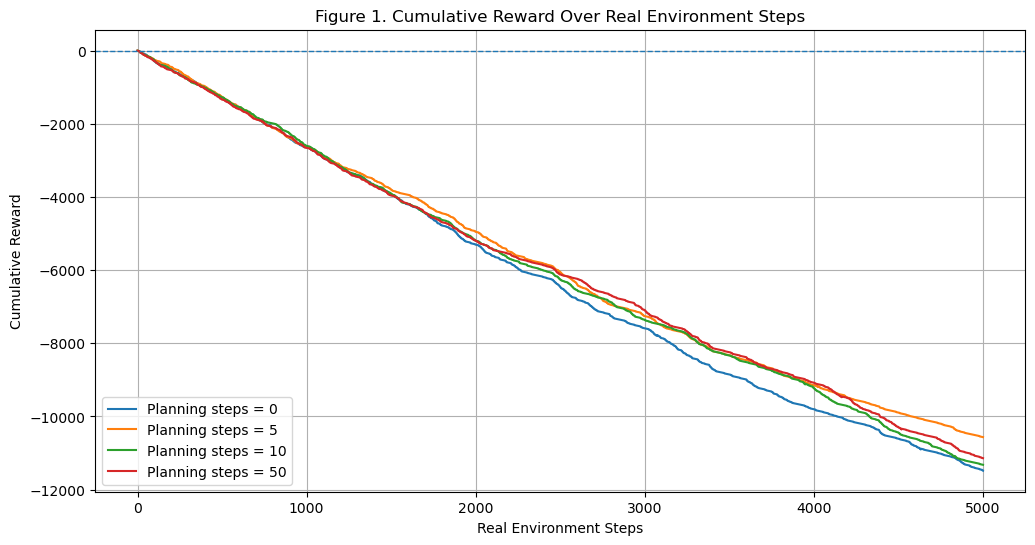

In [5]:
plt.figure(figsize=(12, 6))

for n, result in all_results.items():
    plt.plot(result["cumulative_rewards"], label=f"Planning steps = {n}")

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Real Environment Steps")
plt.ylabel("Cumulative Reward")
plt.title("Figure 1. Cumulative Reward Over Real Environment Steps")
plt.legend()
plt.grid(True)
plt.show()

Figure 1 shows cumulative reward decreasing over 5,000 real environment steps for all methods. This is expected in Taxi because most actions receive negative rewards, especially early in training when the agent makes inefficient moves or illegal pickup/drop-off attempts. The important comparison is which line stays less negative. Dyna-Q with 5 planning steps performs best overall because its curve remains highest by the end. Pure Q-learning with 0 planning steps performs worst, showing that learning only from real experience is slower. Dyna-Q with 10 and 50 planning steps improve slightly, but not as much as 5 steps. This suggests moderate planning helped most.

Step 6: Plot episode lengths as a measure of optimal performance

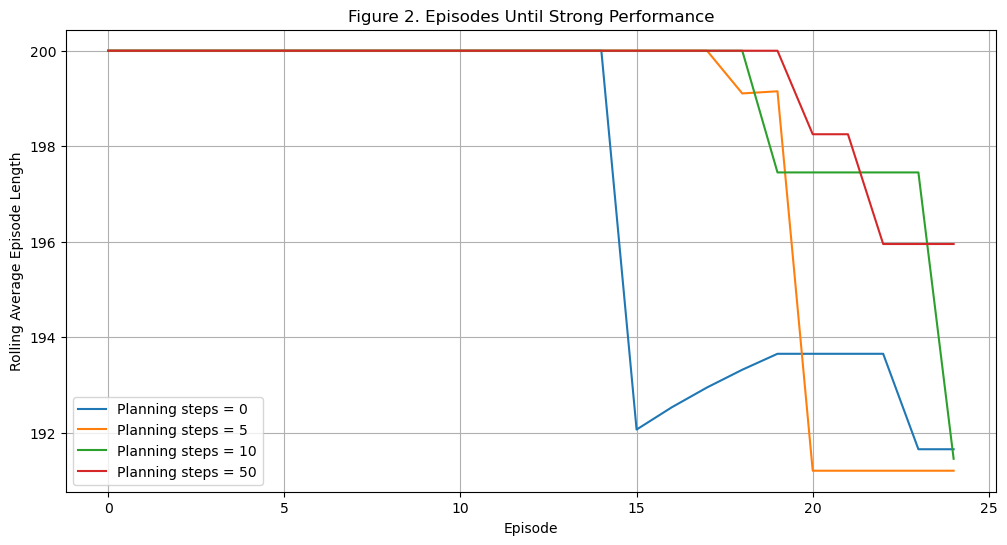

In [6]:
plt.figure(figsize=(12, 6))

for n, result in all_results.items():
    episode_lengths = result["lengths_per_episode"]
    if len(episode_lengths) > 0:
        rolling_lengths = pd.Series(episode_lengths).rolling(window=20, min_periods=1).mean()
        plt.plot(rolling_lengths, label=f"Planning steps = {n}")

plt.xlabel("Episode")
plt.ylabel("Rolling Average Episode Length")
plt.title("Figure 2. Episodes Until Strong Performance")
plt.legend()
plt.grid(True)
plt.show()

Figure 2 shows the rolling average episode length for each planning setting. Lower values are better because they mean the taxi is completing episodes in fewer steps. Most methods stay near 200 steps for much of training, which suggests the agents are still learning slowly and have not reached an efficient policy yet. Pure Q-learning drops earlier around episode 15, but Dyna-Q with 5 planning steps ends with the lowest episode length, around 191 steps. Dyna-Q with 10 and 50 planning steps improve later, but they remain slightly higher. 

Step 7: Calculate sample efficiency

In [7]:
def steps_until_good_performance(lengths, threshold=30, window=20):
    if len(lengths) < window:
        return None
    
    rolling = pd.Series(lengths).rolling(window=window, min_periods=window).mean()
    
    for episode_index, value in enumerate(rolling):
        if not np.isnan(value) and value <= threshold:
            return episode_index + 1
    
    return None


sample_efficiency_rows = []

for n, result in all_results.items():
    episodes_needed = steps_until_good_performance(
        result["lengths_per_episode"],
        threshold=30,
        window=20
    )
    
    if episodes_needed is not None:
        real_steps_needed = sum(result["lengths_per_episode"][:episodes_needed])
    else:
        real_steps_needed = None
    
    sample_efficiency_rows.append({
        "Planning Steps": n,
        "Episodes Until Avg Length <= 30": episodes_needed,
        "Real Steps Needed": real_steps_needed
    })

sample_efficiency_df = pd.DataFrame(sample_efficiency_rows)
print(sample_efficiency_df)

   Planning Steps Episodes Until Avg Length <= 30 Real Steps Needed
0               0                            None              None
1               5                            None              None
2              10                            None              None
3              50                            None              None


The sample efficiency table shows that none of the methods reached the chosen benchmark of an average episode length of 30 steps or less. Pure Q-learning, Dyna-Q with 5 steps, Dyna-Q with 10 steps, and Dyna-Q with 50 steps all failed to achieve good performance inside the 5,000 actual environment steps, as indicated by the outcome of None for each planned setting. This does not imply that the code was unsuccessful. It means the benchmark was too strict for the current amount of training. Since the previous episode-length plot showed averages around 191–196 steps, the agents were still far from the 30-step target.

Dynamic Environment: When Models Go Wrong

Step 8: Create a dynamic Taxi wrapper that adds a new wall after 1,000 steps

In [8]:
class DynamicTaxiWallWrapper(gym.Wrapper):
    def __init__(self, env, change_step=1000):
        super().__init__(env)
        self.change_step = change_step
        self.total_steps = 0
    
    def decode_state(self, state):
        destination = state % 4
        state = state // 4
        passenger = state % 5
        state = state // 5
        taxi_col = state % 5
        taxi_row = state // 5
        return taxi_row, taxi_col, passenger, destination
    
    def crosses_new_wall(self, state, action):
        taxi_row, taxi_col, passenger, destination = self.decode_state(state)
        
        blocks_east = taxi_row == 2 and taxi_col == 2 and action == 2
        blocks_west = taxi_row == 2 and taxi_col == 3 and action == 3
        
        return blocks_east or blocks_west
    
    def reset(self, **kwargs):
        observation, info = self.env.reset(**kwargs)
        return observation, info
    
    def step(self, action):
        current_state = self.unwrapped.s
        
        if self.total_steps >= self.change_step and self.crosses_new_wall(current_state, action):
            self.total_steps += 1
            observation = current_state
            reward = -1
            terminated = False
            truncated = False
            info = {"dynamic_wall_blocked": True}
            return observation, reward, terminated, truncated, info
        
        observation, reward, terminated, truncated, info = self.env.step(action)
        self.total_steps += 1
        return observation, reward, terminated, truncated, info


def make_dynamic_taxi_env(seed=None):
    base_env = make_taxi_env(seed=seed)
    dynamic_env = DynamicTaxiWallWrapper(base_env, change_step=1000)
    return dynamic_env

This wrapper creates a changing environment. After 1,000 real steps, a new wall appears between two grid cells. Before the change, the agent may learn that moving through that area is possible. After the change, the same action no longer works.
This is important because model-based methods depend on their model being accurate. If the environment changes, the old model may keep generating simulated experiences that are no longer true.
That is the main weakness of regular Dyna-Q in changing environments: it may continue planning from outdated transitions.

Step 9: Implement Dyna-Q+

In [9]:
def train_dyna_q_plus(
    planning_steps=10,
    total_real_steps=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1,
    kappa=0.001,
    seed=42,
    use_bonus=True,
    env_builder=make_dynamic_taxi_env
):
    np.random.seed(seed)
    random.seed(seed)
    
    env = env_builder(seed=seed)
    n_states, n_actions = get_env_sizes(env)
    Q = np.zeros((n_states, n_actions))
    
    model = {}
    last_visit = {}
    
    state, info = env.reset(seed=seed)
    episode_reward = 0
    cumulative_reward = 0
    completed_episodes = 0
    
    rewards_per_episode = []
    cumulative_rewards = []
    
    for real_step in range(1, total_real_steps + 1):
        action = epsilon_greedy_action(Q, state, epsilon, env)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        q_learning_update(Q, state, action, reward, next_state, done, alpha, gamma)
        
        model[(state, action)] = (reward, next_state, done)
        last_visit[(state, action)] = real_step
        
        if len(model) > 0:
            model_keys = list(model.keys())
            
            for _ in range(planning_steps):
                sim_state, sim_action = random.choice(model_keys)
                sim_reward, sim_next_state, sim_done = model[(sim_state, sim_action)]
                
                if use_bonus:
                    tau = real_step - last_visit.get((sim_state, sim_action), real_step)
                    sim_reward = sim_reward + kappa * np.sqrt(tau)
                
                q_learning_update(Q, sim_state, sim_action, sim_reward, sim_next_state, sim_done, alpha, gamma)
        
        episode_reward += reward
        cumulative_reward += reward
        cumulative_rewards.append(cumulative_reward)
        
        if done:
            rewards_per_episode.append(episode_reward)
            completed_episodes += 1
            state, info = env.reset()
            episode_reward = 0
        else:
            state = next_state
    
    env.close()
    
    results = {
        "Q": Q,
        "model": model,
        "rewards_per_episode": rewards_per_episode,
        "cumulative_rewards": cumulative_rewards,
        "episodes_completed": completed_episodes,
        "use_bonus": use_bonus,
        "kappa": kappa
    }
    
    return results

Dyna-Q+ adds an exploration bonus during planning.
​	
In simple words: Dyna-Q+ says, “If I have not tried this action in a long time, maybe the world has changed. I should give it a little extra imagined reward so I am encouraged to test it again.”
This matters after the wall appears because the agent needs to discover that some previously valid transitions are no longer valid.


Step 10: Compare regular Dyna-Q and Dyna-Q+

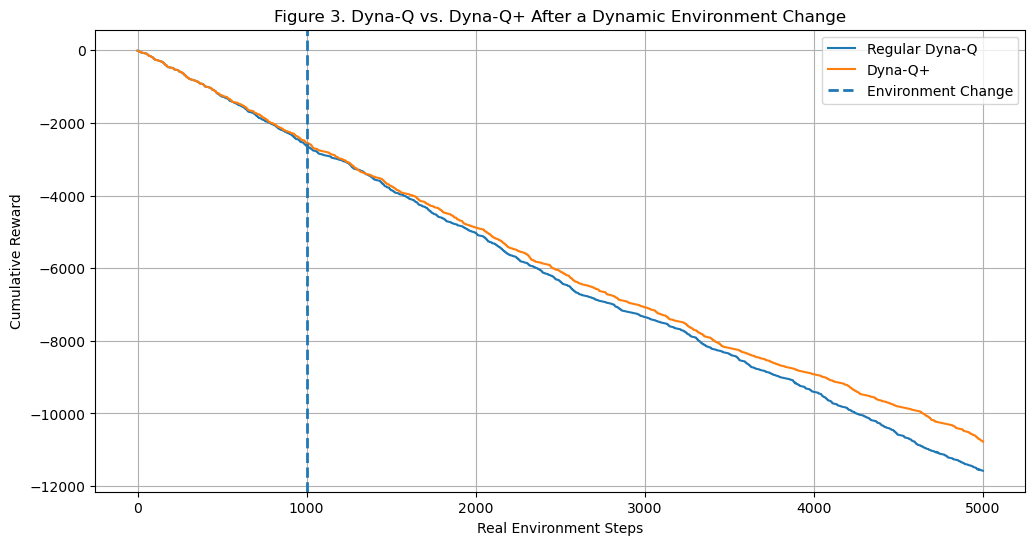

In [10]:
regular_dyna_dynamic = train_dyna_q_plus(
    planning_steps=10,
    total_real_steps=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1,
    kappa=0.001,
    seed=7,
    use_bonus=False,
    env_builder=make_dynamic_taxi_env
)

dyna_q_plus_dynamic = train_dyna_q_plus(
    planning_steps=10,
    total_real_steps=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1,
    kappa=0.001,
    seed=7,
    use_bonus=True,
    env_builder=make_dynamic_taxi_env
)

plt.figure(figsize=(12, 6))
plt.plot(regular_dyna_dynamic["cumulative_rewards"], label="Regular Dyna-Q")
plt.plot(dyna_q_plus_dynamic["cumulative_rewards"], label="Dyna-Q+")
plt.axvline(1000, linestyle="--", linewidth=2, label="Environment Change")
plt.xlabel("Real Environment Steps")
plt.ylabel("Cumulative Reward")
plt.title("Figure 3. Dyna-Q vs. Dyna-Q+ After a Dynamic Environment Change")
plt.legend()
plt.grid(True)
plt.show()

figure 3 shows us a comparison between Dyna-Q and Dyna-Q+ after the environment changes at step 1,000. Since both agents were learning in the same initial taxi environment, it makes natural that their performance was nearly identical prior to the modification. The environment changes after the dashed line, therefore the agent's previous model might not be entirely true. Regular Dyna-Q ends with a smaller cumulative reward as it continues to fall more steeply. After the modification, Dyna-Q+ continuously outperforms standard Dyna-Q, which means it gradually loses reward. This suggests that the exploration bonus helped Dyna-Q+ adapt better to the changed environment. The bonus encourages the agent to revisit state-action pairs that have not been tried recently, which helps it detect that the environment changed. 

Prioritized Sweeping
Step 11: Implement prioritized sweeping

In [11]:
def train_prioritized_sweeping(
    planning_steps=10,
    total_real_steps=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1,
    theta=0.01,
    seed=42,
    env_builder=make_taxi_env
):
    np.random.seed(seed)
    random.seed(seed)
    
    env = env_builder(seed=seed)
    n_states, n_actions = get_env_sizes(env)
    Q = np.zeros((n_states, n_actions))
    
    model = {}
    predecessors = {}
    priority_queue = []
    queued_pairs = set()
    
    state, info = env.reset(seed=seed)
    episode_reward = 0
    episode_length = 0
    cumulative_reward = 0
    completed_episodes = 0
    
    rewards_per_episode = []
    lengths_per_episode = []
    cumulative_rewards = []
    
    for real_step in range(1, total_real_steps + 1):
        action = epsilon_greedy_action(Q, state, epsilon, env)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        model[(state, action)] = (reward, next_state, done)
        
        if next_state not in predecessors:
            predecessors[next_state] = set()
        predecessors[next_state].add((state, action))
        
        if done:
            target = reward
        else:
            target = reward + gamma * np.max(Q[next_state])
        
        priority = abs(target - Q[state, action])
        
        if priority > theta:
            heapq.heappush(priority_queue, (-priority, state, action))
            queued_pairs.add((state, action))
        
        q_learning_update(Q, state, action, reward, next_state, done, alpha, gamma)
        
        for _ in range(planning_steps):
            if len(priority_queue) == 0:
                break
            
            negative_priority, sim_state, sim_action = heapq.heappop(priority_queue)
            
            if (sim_state, sim_action) in queued_pairs:
                queued_pairs.remove((sim_state, sim_action))
            
            sim_reward, sim_next_state, sim_done = model[(sim_state, sim_action)]
            q_learning_update(Q, sim_state, sim_action, sim_reward, sim_next_state, sim_done, alpha, gamma)
            
            for pred_state, pred_action in predecessors.get(sim_state, set()):
                pred_reward, pred_next_state, pred_done = model[(pred_state, pred_action)]
                
                if pred_done:
                    pred_target = pred_reward
                else:
                    pred_target = pred_reward + gamma * np.max(Q[pred_next_state])
                
                pred_priority = abs(pred_target - Q[pred_state, pred_action])
                
                if pred_priority > theta and (pred_state, pred_action) not in queued_pairs:
                    heapq.heappush(priority_queue, (-pred_priority, pred_state, pred_action))
                    queued_pairs.add((pred_state, pred_action))
        
        episode_reward += reward
        episode_length += 1
        cumulative_reward += reward
        cumulative_rewards.append(cumulative_reward)
        
        if done:
            rewards_per_episode.append(episode_reward)
            lengths_per_episode.append(episode_length)
            completed_episodes += 1
            state, info = env.reset()
            episode_reward = 0
            episode_length = 0
        else:
            state = next_state
    
    env.close()
    
    results = {
        "Q": Q,
        "model": model,
        "rewards_per_episode": rewards_per_episode,
        "lengths_per_episode": lengths_per_episode,
        "cumulative_rewards": cumulative_rewards,
        "episodes_completed": completed_episodes
    }
    
    return results

Prioritized sweeping improves planning by being more selective.
Regular Dyna-Q randomly samples from the model. Prioritized sweeping asks a smarter question: “Which state-action pair currently has the biggest expected learning error?”


A large TD error means the Q-value is probably outdated or inaccurate. So instead of planning randomly, prioritized sweeping focuses computation where it can change the value function the most.
The predecessor dictionary is also important. If one state changes value, then the states that lead into it may also need updates. That is how value information moves backward through the environment more efficiently.


Step 12: Compare uniform random planning vs. prioritized sweeping

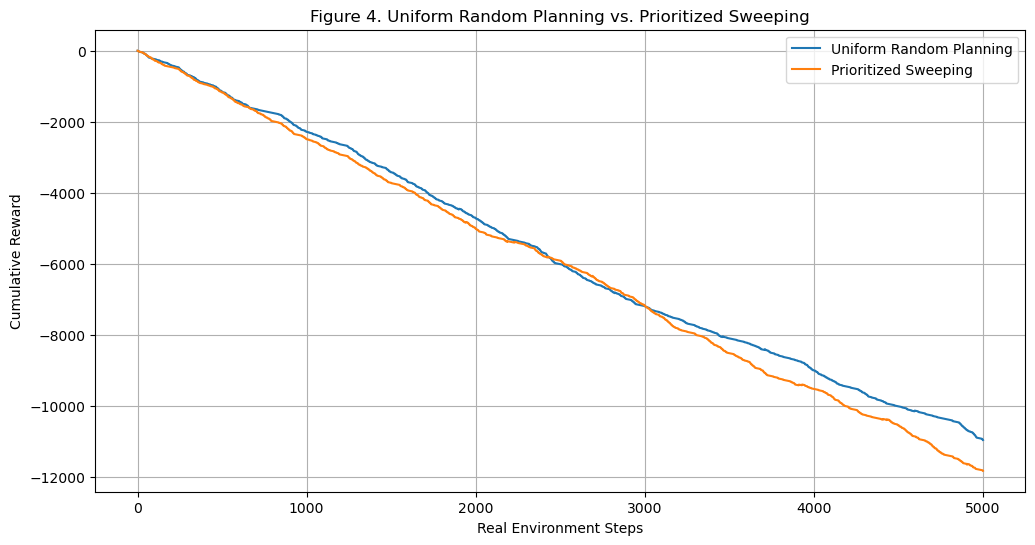

In [12]:
uniform_dyna = train_dyna_q(
    planning_steps=10,
    total_real_steps=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1,
    seed=99,
    env_builder=make_taxi_env
)

prioritized = train_prioritized_sweeping(
    planning_steps=10,
    total_real_steps=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1,
    theta=0.01,
    seed=99,
    env_builder=make_taxi_env
)

plt.figure(figsize=(12, 6))
plt.plot(uniform_dyna["cumulative_rewards"], label="Uniform Random Planning")
plt.plot(prioritized["cumulative_rewards"], label="Prioritized Sweeping")
plt.xlabel("Real Environment Steps")
plt.ylabel("Cumulative Reward")
plt.title("Figure 4. Uniform Random Planning vs. Prioritized Sweeping")
plt.legend()
plt.grid(True)
plt.show()

Figure 4 compares uniform random planning with prioritized sweeping over 5,000 real environment steps. In this run, uniform random planning performs slightly better because its cumulative reward stays less negative by the end. Prioritized sweeping starts close to uniform planning, but after around 3,000 steps, its curve drops more sharply and finishes with lower cumulative reward. This means prioritized sweeping did not improve learning speed in this specific experiment. One possible reason is that the agent may not have trained long enough, or the priority threshold and planning settings may need tuning. Prioritized sweeping is designed to focus updates on high-error transitions, but if the model is still limited or noisy, those focused updates may not help immediately.

Step 13: Create a final comparison table

In [13]:
comparison_rows = []

comparison_agents = {
    "Pure Q-learning": all_results[0],
    "Dyna-Q n=5": all_results[5],
    "Dyna-Q n=10": all_results[10],
    "Dyna-Q n=50": all_results[50],
    "Prioritized Sweeping": prioritized
}

for name, result in comparison_agents.items():
    final_rewards = result["rewards_per_episode"][-20:]
    final_lengths = result["lengths_per_episode"][-20:]
    
    comparison_rows.append({
        "Method": name,
        "Episodes Completed": result["episodes_completed"],
        "Final Avg Reward": np.mean(final_rewards) if len(final_rewards) > 0 else np.nan,
        "Final Avg Episode Length": np.mean(final_lengths) if len(final_lengths) > 0 else np.nan,
        "Model Size": len(result["model"])
    })

final_comparison_df = pd.DataFrame(comparison_rows)
print(final_comparison_df)

                 Method  Episodes Completed  Final Avg Reward  \
0       Pure Q-learning                  25           -424.00   
1            Dyna-Q n=5                  25           -383.95   
2           Dyna-Q n=10                  25           -423.80   
3           Dyna-Q n=50                  25           -417.50   
4  Prioritized Sweeping                  31           -317.80   

   Final Avg Episode Length  Model Size  
0                    191.65        2015  
1                    191.20        1750  
2                    191.45        2010  
3                    195.95        1923  
4                    138.25        2265  


The final comparison table shows that prioritized sweeping had the strongest final performance overall. It completed 31 episodes, more than the other methods, which each completed 25 episodes. Its final average reward was also the best at -317.80, meaning it made fewer costly mistakes and collected less negative reward near the end of training. Additionally, it learned a more effective taxi strategy than the other approaches, as seen by the shorter final average episode duration of 138.25. Dyna-Q with five planning phases outperformed the other Dyna-Q approaches, with an average episode duration of 191.20 and a final average reward of -383.95. With a reward of -424.00, pure Q-learning did not perform as well. Overall, the table suggests that planning improves learning, but smarter planning matters most. Prioritized sweeping used the largest model and focused updates on important transitions, which helped it learn faster and complete more episodes.

Final Synthesis: Planning and Learning Integration



In this lab, the Taxi environment was used to evaluate model-based and model-free reinforcement learning. The primary objective was to determine whether combining simulated planning with actual experience may accelerate an agent's learning. Model-based techniques were represented by Dyna-Q, Dyna-Q+, and prioritized sweeping, whilst model-free approaches were represented by pure Q-learning.

When the environment is hard to model, unexpected, or changes often, model-free approaches should be employed. The agent in pure Q-learning does not construct an environment model. It only gains knowledge from actual experience when an action is taken, the reward and subsequent state are seen, and the Q-table is updated. In situations when a model may be wrong, this makes model-free learning easier and safer. The drawback is that learning a good policy typically requires more real-world interactions. Because each improvement in this experiment relied on actual Taxi steps, pure Q-learning learnt more slowly.

Model-based methods should be used when real environment interaction is expensive, limited, or risky. Dyna-Q builds a simple model using a Python dictionary that stores observed transitions. After each real step, the agent uses the model to generate simulated experiences and perform extra Q-learning updates. This allows the agent to learn from both real experience and imagined experience. In the Taxi task, this helped because the agent could reuse previous transitions instead of waiting to experience the same situation again.

Sample complexity compares how many real environment interactions are needed to reach good performance. Model-based methods usually have better sample efficiency because one real step can produce many learning updates through planning. In the results, Dyna-Q with 5 planning steps performed better than pure Q-learning, showing that planning helped the agent learn more from limited real experience. However, more planning was not always better. Dyna-Q with 10 or 50 planning steps did not clearly outperform 5 planning steps, which suggests that too much planning can reuse an incomplete or imperfect model too heavily.

The main computational trade-off is that model-free methods are simpler and cheaper, while model-based methods require more computation and memory. Pure Q-learning performs one update per real step. Dyna-Q performs one real update plus several simulated updates. Prioritized sweeping adds even more complexity because it uses a priority queue and tracks predecessor states. However, prioritized sweeping can make planning more efficient by focusing updates on transitions with large TD errors instead of sampling randomly.

Model errors are a major weakness of model-based methods. If the learned model is accurate, planning improves learning. If the model is wrong or outdated, the agent may learn from bad simulated experiences. This appeared in the dynamic environment experiment, where a new wall was added after 1,000 steps. Regular Dyna-Q could continue planning from old transitions that were no longer correct. Dyna-Q+ handled this better by using an exploration bonus, encouraging the agent to revisit actions that had not been tried recently.